In [1]:
# Imports
import os
from pathlib import Path
markers = (".git", "Program")
current_dir = Path.cwd()
project_root = next((path for path in (current_dir, *current_dir.parents) if any((path / marker).exists() for marker in markers)), current_dir)
os.chdir(project_root)

from backtest import *
import concurrent.futures
import cvxpy as cp
import datetime as dt
from functools import partial
from fundamentals import *
from helper_functions import modify_current_date, get_df, get_excel_filename, get_infix, get_volume5m_data, generate_end_dates, merge_stocks, stock_market
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math
import multiprocessing
import numpy as np
import pandas as pd
from pandas import ExcelWriter as EW
from plot import *
import random
from scipy.optimize import minimize
from scipy.stats import false_discovery_control, kendalltau, linregress, pearsonr, spearmanr, ttest_ind, wilcoxon
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from stock_screener import check_conds_tech, check_conds_fund, EM_rating, get_stock_info, stoploss_target
from technicals import *
from tqdm import tqdm

# Connect to TradingView
from tvDatafeed import TvDatafeed, Interval
tv = TvDatafeed()

# Start of the program
start = dt.datetime.now()

# Index
index_name = "^GSPC"
index_dict = {"^HSI": "HKEX", "^GSPC": "S&P 500", "^IXIC": "NASDAQ Composite"}

# Modify the current date
current_date = modify_current_date(start, index_name)

you are using nologin method, data you access may be limited


In [2]:
# --- Select Stock Universe from Excel File ---
# Load pre-screened stocks from the stock screener output file
def extract_metadata(current_date, index_name, index_dict, period=252, RS=90, all_stocks=True, cap_threshold=10):
    """
    Extracts the stock universe and filters for Market Cap and all Trend/Growth conditions.
    """
    excel_filename = get_excel_filename(current_date, index_name, index_dict, period, RS, all_stocks)
    excel_df = pd.read_excel(excel_filename)

    # Dynamically identify the Market Cap column (e.g., USD, HKD, CNY)
    market_cap_matches = [col for col in excel_df.columns if re.match(r"Market Cap \(B, .*", col)]
    
    if not market_cap_matches:
        print(f"Warning: No Market Cap column found for {current_date}. Skipping cap filter.")
        # If no cap column, we just create a mask of all True to avoid crashing
        market_cap_mask = pd.Series([True] * len(excel_df))
        market_cap_col = None
    else:
        market_cap_col = market_cap_matches[0]
        market_cap_mask = excel_df[market_cap_col] > cap_threshold
    
    # Check if all condition columns exist in the current Excel file
    cond_cols = ["cond_t1", "cond_t3", "cond_t4", "cond_t5", "cond_f2", "cond_f3"]
    has_all_conds = set(cond_cols).issubset(excel_df.columns)
    
    # Construct the filtering mask
    mask = market_cap_mask
    if has_all_conds:
        # Modern file logic: Add the requirement that ALL conditions must be True
        mask = mask & excel_df[cond_cols].all(axis=1)
        print(f"Applied full filters for {current_date}. Found {mask.sum()} stocks.")
    else:
        # Legacy file logic: Fallback to only Market Cap
        pass 
        print(f"Columns missing for {current_date}. Falling back to Market Cap only.")
    
    # Extract metadata (avoid SettingWithCopy); include Market Cap if present
    info_cols = ["Stock"] + ([market_cap_col] if market_cap_col else [])
    metadata_df = excel_df.loc[mask, info_cols].copy()

    # Standardize the Market Cap column name
    if market_cap_col:
        metadata_df.rename(columns={market_cap_col: "Market Cap"}, inplace=True)
    
    return metadata_df.reset_index(drop=True)

# --- Fetch Price Data ---
# Fetch historical closing prices for all stocks
def fetch_price_data(stocks, current_date, min_required_days=252, benchmark="^GSPC"):
    # Include S&P 500 in the calculation
    all_tickers = stocks + [benchmark]
    price_data = {}
    valid_stocks = []

    for stock in tqdm(all_tickers, desc="Fetching price data"):
        try:
            df = get_df(stock, current_date)
            if df is None or df.empty:
                continue
            
            # Ensure data is up to current_date
            df = df[df.index <= current_date]
            
            # Key check: data length must be sufficient to support your backtest window (252 days)
            if len(df) < min_required_days:
                print(f"Warning: {stock} has insufficient data ({len(df)} days). Skipping...")
                continue
                
            price_data[stock] = df["Close"]
            if stock != benchmark:
                valid_stocks.append(stock)
        except Exception as e:
            print(f"Error fetching {stock}: {e}")
            continue

    return price_data, valid_stocks

# --- Weekly Returns Z-Score Analysis ---
# Z-score measures how unusual this week's return is vs historical weekly returns
# High z-score (>2) = unusually strong week, may indicate temporary spike
def compute_weekly_return_zscores(price_data, valid_stocks, period_week_zscore, days_per_week):
    df_prices_weekly = pd.DataFrame({stock: price_data[stock].tail(period_week_zscore + days_per_week) for stock in valid_stocks})
    weekly_prices = df_prices_weekly.iloc[::days_per_week]
    weekly_returns = weekly_prices.pct_change(fill_method=None).dropna()

    mean_return = weekly_returns.mean()
    std_return = weekly_returns.std()
    recent_return = weekly_returns.iloc[-1]
    z_scores = (recent_return - mean_return) / std_return

    return weekly_returns, mean_return, std_return, recent_return, z_scores

# --- Momentum and Volatility Analysis ---
# Momentum: price ratio (recent / year-ago) - measures trend strength over 1 year
# Volatility: standard deviation of daily returns - measures price variability
# Vol-adj Momentum: momentum / volatility - risk-adjusted trend
def calculate_momentum_volatility(price_data, valid_stocks, period_mom_short, period_mom_long, period_vol, benchmark="^GSPC"):
    """
    Calculates Total Momentum, Idiosyncratic Momentum, and Volatility.
    
    Parameters:
    - price_data: DataFrame with columns as tickers and rows as dates ("Close").
    - valid_stocks: List of stock tickers to analyze.
    - period_mom_short: The "recent" exclusion period (e.g., 21 for 1 month).
    - period_mom_long: The lookback period (e.g., 252 for 1 year).
    - period_vol: Lookback for volatility (e.g., 60).
    - benchmark: Ticker for the market index (e.g., ^GSPC).
    
    Returns:
    - momentum_list, idio_momentum_list, volatility_list
    """
    # Include S&P 500 in the calculation
    all_tickers = valid_stocks + [benchmark]

    # Ensure benchmark data is available
    if benchmark not in price_data:
        raise ValueError("Benchmark data missing. Cannot compute idiosyncratic momentum.")
    
    # Build DataFrame once for vectorized operations
    df_prices = pd.DataFrame({stock: price_data[stock].tail(period_mom_long + 1) for stock in all_tickers})

    # Vectorized calculation of daily returns
    daily_returns = df_prices.pct_change(fill_method=None).dropna()

    # Vectorized volatility calculation: std of daily returns over period_vol
    volatility_series = daily_returns[valid_stocks].tail(period_vol).std()
    
    # Vectorized calculation of total momentum
    momentum_series = df_prices[valid_stocks].iloc[- period_mom_short] / df_prices[valid_stocks].iloc[- period_mom_long] - 1
    
    # Vectorized beta calculation
    # We calculate the covariance matrix of ALL stocks + Benchmark
    # Then we select only the column corresponding to the benchmark
    cov_matrix = daily_returns.cov()
    cov_with_benchmark = cov_matrix[benchmark].loc[valid_stocks] # Filter for just our stocks
    beta_series = cov_with_benchmark / daily_returns[benchmark].var()
    
    # Calculate idiosyncratic momentum
    # Formula: r_idio = r_stock - (beta * r_market)
    
    # Calculate benchmark return over the same specific window
    benchmark_return = df_prices[benchmark].iloc[- period_mom_short] / df_prices[benchmark].iloc[- period_mom_long] - 1
    
    # Calculate residuals
    idio_momentum_series = momentum_series - (beta_series * benchmark_return)

    # Convert series to lists
    return momentum_series.tolist(), idio_momentum_series.tolist(), volatility_series.tolist()

# --- Hierarchical Clustering Analysis ---
# Groups stocks by return correlation using Ward's linkage (minimizes within-cluster variance)
def hierarchical_clustering(price_data, valid_stocks, period_pca, num_clusters):
    # Ensure we have at least 2 stocks to cluster
    if len(valid_stocks) < 2:
        return None, np.array([1] * len(valid_stocks))

    # Build the price dataframe
    df_prices_cluster = pd.DataFrame({stock: price_data[stock].tail(period_pca) for stock in valid_stocks})
    
    # Calculate returns
    returns = df_prices_cluster.pct_change(fill_method=None)
    
    # Check if we have enough valid rows to calculate correlation
    # We need at least 2 rows of returns to have a correlation
    if len(returns.dropna(how="all")) < 2:
        print(f"Warning: Not enough data for clustering in this period. Skipping...")
        return None, np.array([1] * len(valid_stocks))

    # Correlation Matrix
    corr_matrix = returns.corr()
    
    # Handle NaNs in the correlation matrix (caused by zero volatility/flat prices)
    corr_matrix = corr_matrix.fillna(0)
    
    # Convert to distance matrix
    dist_matrix = np.sqrt(2 * (1 - corr_matrix))
    
    # Hierarchical clustering
    try:
        # squareform() expects a symmetric matrix with 0s on the diagonal
        condensed_dist = squareform(dist_matrix, checks=False)
        
        if condensed_dist.size == 0:
            raise ValueError("Condensed distance matrix is empty.")
            
        Z = linkage(condensed_dist, method="ward")
        cluster_labels = fcluster(Z, t=num_clusters, criterion="maxclust")
        return Z, cluster_labels
        
    except Exception as e:
        print(f"Clustering failed: {e}")
        # Fallback: Assign everyone to Cluster 1
        return None, np.array([1] * len(valid_stocks))

# --- Combine All Metrics into Single DataFrame ---
def create_combined_dataframe(valid_stocks, metadata_df, cluster_labels, momentum_list, idio_momentum_list, volatility_list, 
                               mean_return, std_return, recent_return, z_scores):
    """
    Consolidate all computed metrics into a single DataFrame for analysis.
    Adds vol-adjusted momentum and ranks stocks by this metric.
    """
    df_combined = pd.DataFrame({
        "Stock": valid_stocks,
        "Cluster": cluster_labels,
        "Momentum": momentum_list,
        "Idio Momentum": idio_momentum_list,
        "Volatility": volatility_list,
        "Mean Weekly Return (%)": (mean_return * 100).values,
        "Std Weekly Return (%)": (std_return * 100).values,
        "This Week Return (%)": (recent_return * 100).values,
        "Z-Score": z_scores.values
    })

    # --- Merge with stock metadata (e.g., Market Cap)
    # We use a "left" join to keep only the valid stocks that passed the price-fetch stage
    df_combined = df_combined.merge(metadata_df, on="Stock", how="left")
    
    # Vol-adjusted momentum: normalize momentum by volatility for risk-adjusted comparison
    df_combined["Vol-adj Momentum"] = df_combined["Momentum"] / df_combined["Volatility"]
    df_combined["Vol-adj Idio Momentum"] = df_combined["Idio Momentum"] / df_combined["Volatility"]
    
    # Sort by vol-adjusted momentum (descending) and create rank index starting from 1
    df_combined = df_combined.sort_values("Vol-adj Momentum", ascending=False).reset_index(drop=True)
    df_combined.index = df_combined.index + 1
    df_combined.index.name = "Rank"
    return df_combined

# --- Dendrogram Visualization ---
def plot_dendrogram(Z, valid_stocks, period_pca):
    """
    Visualize hierarchical clustering structure as a dendrogram.
    Y-axis (distance) shows how dissimilar clusters are when merged.
    """
    plt.figure(figsize=(14, 8))
    dendrogram(Z, labels=valid_stocks, leaf_rotation=90, leaf_font_size=8)
    plt.title(f"Hierarchical Clustering of {len(valid_stocks)} Stocks (Past {period_pca} Days)")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()

# --- Filter and Display Stocks by Cluster ---
# Exclude stocks with z-score > 2 (unusually high recent returns)
# These may be experiencing unsustainable spikes rather than steady momentum
def filter_stocks_by_zscore(df_combined, z_score_threshold=2):
    """Filter stocks and display by cluster."""
    df_filtered = df_combined[df_combined["Z-Score"] <= z_score_threshold]

    print(f"Stocks by Cluster (Ranked by Vol-adj Momentum, Z-Score <= {z_score_threshold}):")
    for cluster_id in sorted(df_filtered["Cluster"].unique()):
        cluster_df = df_filtered[df_filtered["Cluster"] == cluster_id]
        cluster_stocks = cluster_df["Stock"].tolist()
        print(f"Cluster {cluster_id} ({len(cluster_df)} stocks): {', '.join(cluster_stocks)}")
    
    return df_filtered

def select_top_stocks_with_weights(df_combined, num_stocks, use_hca=True, cluster_cap=0.4):
    """
    Select top stocks using HCA cluster-aware selection or simple momentum.
    """
    if df_combined.empty or df_combined is None:
        return pd.DataFrame()
    
    # Ensure the dataframe is sorted by vol-adjusted momentum before ranking
    df_copy = df_combined.sort_values("Vol-adj Momentum", ascending=False).copy()

    # Assign intra-cluster rank
    df_copy["Intra-cluster Rank"] = df_copy.groupby("Cluster").cumcount()

    if use_hca:
        # Sort: First by intra-cluster rank, then by the original sort order (Vol-adj Momentum)
        top_stocks = df_copy.sort_values(by=["Intra-cluster Rank", "Vol-adj Momentum"], ascending=[True, False]).head(num_stocks)

    else:
        # Calculate the dynamic limit per cluster
        max_per_cluster = math.ceil(num_stocks * (cluster_cap if cluster_cap else 1.0))
        # Simple momentum selection
        top_stocks = df_copy[df_copy["Intra-cluster Rank"] < max_per_cluster].head(num_stocks)

    # Define target weights (inverse volatility)
    volatilities = top_stocks["Volatility"].values
    inv_vol = 1 / volatilities
    target_weights = inv_vol / inv_vol.sum()

    if cluster_cap is None:
        # Use target weights directly (no cluster cap)
        weights = target_weights
    else:
        # --- Convex Optimization using CVXPY ---
        clusters = top_stocks["Cluster"].values
        unique_clusters = np.unique(clusters)
    
        # Variable: The weights we want to find
        num_stocks = len(top_stocks)
        w = cp.Variable(num_stocks)

        # Objective: Minimize squared distance from target weights (tracking error)
        # This is a quadratic objective
        objective = cp.Minimize(cp.sum_squares(w - target_weights))

        # Constraints
        constraints = [
            cp.sum(w) == 1.0, # Fully invested
            w >= 0 # Long only (no shorting)
        ]

        # Check if cluster cap is mathematically possible
        is_feasible = cluster_cap is not None and (len(unique_clusters) * cluster_cap >= 1.0)

        # Cluster constraints
        if is_feasible:
            # Find the integer indices of stocks belonging to this cluster
            for cluster in unique_clusters:
                indices = [i for i, c_val in enumerate(clusters) if c_val == cluster]
                constraints.append(cp.sum(w[indices]) <= cluster_cap)
        else:
            if num_stocks > 0:
                print(f"Warning: cluster_cap {cluster_cap} is impossible with {len(unique_clusters)} clusters. Relaxing cap.")

        # OSQP solver
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.OSQP)

        # Get results
        if w.value is None:
            # Fallback (Theoretical only; convex problems shouldn't fail unless constraints are impossible)
            print("Optimization failed. Using target weights.")
            weights = target_weights
        else:
            weights = w.value
            # Re-normalize just to be safe after rounding
            weights = weights / np.sum(weights)
        
    return pd.DataFrame({
        "Cluster": top_stocks["Cluster"],
        "Stock": top_stocks["Stock"],
        "Market Cap": top_stocks["Market Cap"],
        "Volatility": volatilities,
        "Vol-adj Momentum": top_stocks["Vol-adj Momentum"],
        "Vol-adj Idio Momentum": top_stocks["Vol-adj Idio Momentum"],
        "Z-Score": top_stocks["Z-Score"],
        "Weight (%)": weights * 100,
    })

In [3]:
# --- Main Monthly Portfolio Construction Function ---
def construct_month_portfolio(current_date, index_name, index_dict, parameters, use_hca=True, cluster_cap=0.4):
    """
    Construct a monthly momentum portfolio based on hierarchical clustering and vol-adjusted momentum.
    """
    # Extract stocks
    metadata_df = extract_metadata(current_date, index_name, index_dict)
    stocks = metadata_df["Stock"].tolist()

    # Check if we have enough stocks
    if len(stocks) < 1:
        print("Not enough stocks to construct a portfolio.")
        return pd.DataFrame(), 0
    
    # Fetch price data
    price_data, valid_stocks = fetch_price_data(stocks, current_date)
    
    # Weekly returns z-score analysis
    weekly_returns, mean_return, std_return, recent_return, z_scores = compute_weekly_return_zscores(
        price_data, valid_stocks, parameters["period_week_zscore"], parameters["days_per_week"])
    
    # Momentum and volatility calculation
    momentum_list, idio_momentum_list, volatility_list = calculate_momentum_volatility(
        price_data, valid_stocks, parameters["period_mom_short"], parameters["period_mom_long"], parameters["period_vol"])
    
    # Hierarchical clustering
    Z, cluster_labels = hierarchical_clustering(price_data, valid_stocks, parameters["period_pca"], parameters["num_clusters"])
    
    # Create combined DataFrame
    df_combined = create_combined_dataframe(
        valid_stocks, metadata_df, cluster_labels, momentum_list, idio_momentum_list, volatility_list,
        mean_return, std_return, recent_return, z_scores)
    
    # Filter stocks by z-score
    df_filtered = filter_stocks_by_zscore(df_combined)

    # Extract number of stocks after filtering
    num_stocks_filtered = len(df_filtered)
    print(f"Number of stocks after Z-Score filtering: {num_stocks_filtered}")
    
    # Select top stocks with weights
    portfolio_df = select_top_stocks_with_weights(df_filtered, num_stocks=parameters["num_stocks"], use_hca=use_hca, cluster_cap=cluster_cap)
    
    return portfolio_df, num_stocks_filtered

Applied full filters for 2026-01-17. Found 79 stocks.


Fetching price data:  36%|███▋      | 29/80 [00:00<00:01, 50.44it/s]

Fetching price data: 100%|██████████| 80/80 [00:01<00:00, 51.45it/s]


,Stock,Cluster,Momentum,Idio Momentum,Volatility,Mean Weekly Return (%),Std Weekly Return (%),This Week Return (%),Z-Score,Market Cap,Vol-adj Momentum,Vol-adj Idio Momentum
Rank,,,,,,,,,,,,
1,SAN,3,1.364008,1.230085,0.014412,2.009355,4.033366,0.413567,-0.395647,180.85,94.641089,85.348879
2,SBSW,1,3.097059,2.951579,0.036112,3.466397,9.093006,11.228532,0.853638,12.05,85.763418,81.734820
3,PUK,3,0.973168,0.853814,0.011467,1.376924,3.553382,-1.271317,-0.745274,40.55,84.869243,74.460525
4,BBVA,3,1.106642,1.004531,0.014078,1.839273,4.008964,0.124013,-0.427856,138.58,78.606901,71.353774
5,B,1,1.766349,1.698191,0.023761,2.317892,4.787454,7.192822,1.018272,83.32,74.339362,71.470816
6,AU,1,2.134594,2.078530,0.031503,3.008715,7.565389,9.178247,0.815494,50.00,67.758529,65.978891
7,KGC,1,1.731183,1.667377,0.026073,2.582089,5.340899,13.118124,1.972708,41.15,66.397175,63.949983
8,GFI,1,1.956262,1.916933,0.033030,2.684086,6.302663,9.250508,1.041849,44.47,59.226975,58.036267
9,MT,5,0.950388,0.783686,0.016083,1.522356,5.053405,2.418658,0.177366,37.06,59.091705,48.726781


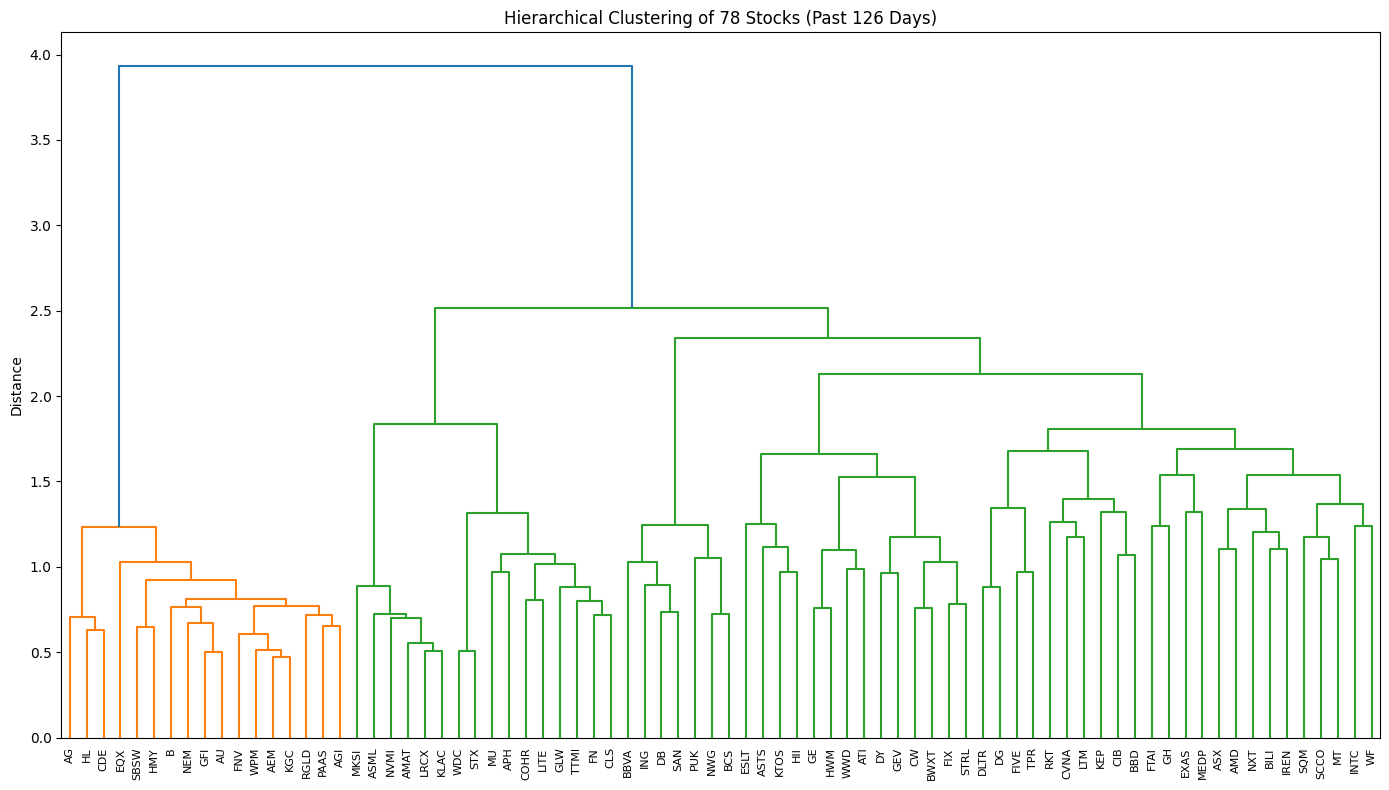

Stocks by Cluster (Ranked by Vol-adj Momentum, Z-Score <= 2):
Cluster 1 (16 stocks): SBSW, B, AU, KGC, GFI, NEM, EQX, WPM, AG, CDE, AEM, PAAS, FNV, AGI, HMY, RGLD
Cluster 2 (16 stocks): WDC, STX, LITE, APH, CLS, GLW, LRCX, MU, TTMI, KLAC, FN, COHR, ASML, AMAT, MKSI, NVMI
Cluster 3 (7 stocks): SAN, PUK, BBVA, DB, BCS, ING, NWG
Cluster 4 (12 stocks): ATI, GE, HWM, DY, HII, ASTS, CW, WWD, FIX, GEV, BWXT, STRL
Cluster 5 (22 stocks): MT, CIB, KEP, FIVE, LTM, WF, GH, DLTR, DG, MEDP, TPR, BBD, IREN, EXAS, INTC, NXT, SQM, CVNA, AMD, RKT, ASX, FTAI
Number of stocks after Z-Score filtering: 73


,Cluster,Stock,Market Cap,Volatility,Vol-adj Momentum,Vol-adj Idio Momentum,Z-Score,Weight (%)
Rank,,,,,,,,
1,3,SAN,180.85,0.014412,94.641089,85.348879,-0.395647,16.911310
2,1,SBSW,12.05,0.036112,85.763418,81.734820,0.853638,14.353457
3,3,PUK,40.55,0.011467,84.869243,74.460525,-0.745274,23.088690
5,1,B,83.32,0.023761,74.339362,71.470816,1.018272,19.342065
9,5,MT,37.06,0.016083,59.091705,48.726781,0.177366,26.304478


In [4]:
# --- Parameters ---
days_per_week = 5  # Trading days in a week
num_weeks = 52  # Weeks in a year
period_week_zscore = days_per_week * num_weeks  # 1-year lookback for weekly return z-score
period_pca = 126  # 6-month lookback for PCA clustering
period_mom_short = 21  # 1-month lookback for short-term momentum
period_mom_long = 252  # 1-year lookback for long-term momentum
period_vol = 60  # 3-month volatility window
num_clusters = 5  # Number of clusters for hierarchical grouping
num_stocks = 5  # Number of stocks to select for the portfolio
parameters = {
    "days_per_week": days_per_week,
    "period_week_zscore": period_week_zscore,
    "period_pca": period_pca,
    "period_mom_short": period_mom_short,
    "period_mom_long": period_mom_long,
    "period_vol": period_vol,
    "num_clusters": num_clusters,
    "num_stocks": num_stocks
}

# --- Extract Stocks ---
metadata_df = extract_metadata("2026-01-17", index_name, index_dict)
stocks = metadata_df["Stock"].tolist()

# --- Fetch Price Data ---
price_data, valid_stocks = fetch_price_data(stocks, "2026-01-17")

# --- Compute Weekly Return Z-Scores ---
weekly_returns, mean_return, std_return, recent_return, z_scores = compute_weekly_return_zscores(
    price_data, valid_stocks, period_week_zscore, days_per_week
)

# --- Calculate Momentum and Volatility ---
momentum_list, idio_momentum_list, volatility_list = calculate_momentum_volatility(price_data, valid_stocks, period_mom_short, period_mom_long, period_vol)

# --- Hierarchical Clustering Analysis ---
Z, cluster_labels = hierarchical_clustering(price_data, valid_stocks, period_pca, num_clusters)

# --- Create Combined DataFrame ---
df_combined = create_combined_dataframe(
    valid_stocks, metadata_df, cluster_labels, momentum_list, idio_momentum_list, volatility_list,
    mean_return, std_return, recent_return, z_scores
)

# --- Display Results ---
pd.set_option("display.max_rows", None)
display(df_combined)
plot_dendrogram(Z, valid_stocks, period_pca)

# --- Filter Stocks by Z-Score and Display by Cluster ---
df_filtered = filter_stocks_by_zscore(df_combined)
current_portfolio_df = select_top_stocks_with_weights(df_filtered, num_stocks, use_hca=False, cluster_cap=0.4)
num_stocks_filtered = len(df_filtered)
print(f"Number of stocks after Z-Score filtering: {num_stocks_filtered}")
display(current_portfolio_df)

In [5]:
# --- Rebalance dates for monthly portfolio analysis ---
rebalance_dates = [
    "2024-02-01", "2024-03-01", "2024-04-01", "2024-05-01", "2024-05-31",
    "2024-07-01", "2024-08-03", "2024-08-31", "2024-10-03", "2024-11-02", "2024-11-30",
    "2025-01-04", "2025-02-01", "2025-03-01", "2025-04-05", "2025-05-01", "2025-06-03",
    "2025-07-01", "2025-08-01", "2025-09-06", "2025-10-01", "2025-11-01", "2025-12-04", 
    "2026-01-03"
]

In [6]:
# --- Construct Monthly Portfolios ---
monthly_portfolios_hca = {}
monthly_portfolios_nohca_cap40 = {} # No HCA with 40% cluster cap
monthly_portfolios_nohca_nocap = {} # No HCA without cluster cap
num_stocks_filtered_list = []
for date in rebalance_dates:
    # With Hierarchical Clustering Analysis
    portfolio_df, num_stocks_filtered = construct_month_portfolio(date, index_name, index_dict, parameters)
    monthly_portfolios_hca[date] = portfolio_df
    num_stocks_filtered_list.append(num_stocks_filtered)
    print(f"\nPortfolio for {date} with HCA:\n")
    display(portfolio_df)
    # Without Hierarchical Clustering Analysis (40% cluster cap)
    portfolio_df, num_stocks_filtered = construct_month_portfolio(date, index_name, index_dict, parameters, use_hca=False)
    monthly_portfolios_nohca_cap40[date] = portfolio_df
    print(f"\nPortfolio for {date} without HCA (40% cluster cap):\n")
    display(portfolio_df)
    # Without Hierarchical Clustering Analysis (no cluster cap)
    portfolio_df, num_stocks_filtered = construct_month_portfolio(date, index_name, index_dict, parameters, use_hca=False, cluster_cap=None)
    monthly_portfolios_nohca_nocap[date] = portfolio_df
    print(f"\nPortfolio for {date} without HCA (no cluster cap):\n")
    display(portfolio_df)

Columns missing for 2024-02-01. Falling back to Market Cap only.


Fetching price data: 100%|██████████| 36/36 [00:00<00:00, 47.43it/s]


Stocks by Cluster (Ranked by Vol-adj Momentum, Z-Score <= 2):
Cluster 1 (2 stocks): NVO, JHX
Cluster 2 (4 stocks): PH, TT, HUBB, RACE
Cluster 3 (2 stocks): FCNCA, ERIE
Cluster 4 (17 stocks): VRT, META, UBER, ANET, MSFT, DECK, PANW, CMG, AMZN, NOW, ADBE, INTU, CRM, GOOG, GOOGL, CDNS, DT
Cluster 5 (9 stocks): APP, SMCI, NU, MANH, KKR, SAP, XP, ISRG, MELI
Number of stocks after Z-Score filtering: 34

Portfolio for 2024-02-01 with HCA:



,Cluster,Stock,Market Cap,Volatility,Vol-adj Momentum,Vol-adj Idio Momentum,Z-Score,Weight (%)
Rank,,,,,,,,
1,4,VRT,14.44,0.023289,90.172841,78.841644,-0.387806,16.011314
3,5,APP,14.26,0.032574,57.102160,49.858601,0.522625,11.447302
5,3,FCNCA,20.07,0.016527,48.114214,37.958327,0.448902,22.562315
13,1,NVO,464.99,0.015820,30.978242,26.931731,0.010681,23.570151
20,2,PH,60.06,0.014120,26.285593,13.445275,-0.149527,26.408917


Columns missing for 2024-02-01. Falling back to Market Cap only.


...

Columns missing for 2026-01-03. Falling back to Market Cap only.


Fetching price data:  24%|██▎       | 18/76 [00:00<00:01, 51.73it/s]

Fetching price data: 100%|██████████| 76/76 [00:01<00:00, 51.87it/s]

Stocks by Cluster (Ranked by Vol-adj Momentum, Z-Score <= 2):
Cluster 1 (15 stocks): AU, SBSW, KGC, B, GFI, HL, EQX, NEM, AEM, FNV, HMY, WPM, PAAS, AGI, RGLD
Cluster 2 (15 stocks): WDC, STX, APH, LITE, MU, LRCX, KLAC, GLW, FN, ASML, CVNA, NVMI, JBL, ASX, COHR
Cluster 3 (16 stocks): HWM, LTM, DY, GE, C, NRG, ATI, FIX, HII, WWD, ASTS, MTZ, CRS, GEV, RKLB, FTAI
Cluster 4 (7 stocks): SAN, BBVA, PUK, DB, ING, BCS, NWG
Cluster 5 (21 stocks): IONS, CIB, KEP, GH, WF, BSAC, MT, ESLT, INTC, FUTU, CAH, TPR, NTES, SQM, FIVE, SCCO, DLTR, MDB, EXAS, DG, ALB
Number of stocks after Z-Score filtering: 74

Portfolio for 2026-01-03 without HCA (no cluster cap):



,Cluster,Stock,Market Cap,Volatility,Vol-adj Momentum,Vol-adj Idio Momentum,Z-Score,Weight (%)
Rank,,,,,,,,
1,4,SAN,177.28,0.015481,90.235245,79.505918,-0.123896,22.407410
2,4,BBVA,135.96,0.016677,75.137957,67.518168,-0.121330,20.800246
3,4,PUK,40.03,0.012024,72.314240,59.921919,0.639150,28.849546
4,5,IONS,12.90,0.018726,71.608566,65.039663,0.182540,18.524175
5,1,AU,43.22,0.036830,71.137981,69.465514,0.489994,9.418623


In [7]:
# Pre-calculate daily returns for portfolios
def get_period_returns(portfolio, period_dates, buy_date, sell_date, sp500_df):
    # Check if portfolio is empty or None
    if portfolio is None or portfolio.empty:
        # FALLBACK: Use S&P 500 returns
        prices = sp500_df["Close"].reindex(period_dates).ffill()

        # Check if buy_date exists in the index
        if buy_date not in sp500_df.index:
            return pd.Series(1.0, index=period_dates)
        
        # Handle execution: Buy at Open of buy_date
        first_day_open = sp500_df.loc[buy_date, "Open"]
        first_day_ret = prices.iloc[0] / first_day_open
        other_days_ret = prices / prices.shift(1)
        other_days_ret.iloc[0] = first_day_ret
        return other_days_ret
        
    # NORMAL LOGIC: Calculate weighted stock returns
    rets_list = []
    for _, row in portfolio.iterrows():
        ticker = row["Stock"]
        weight = row["Weight (%)"] / 100
        sell_date_str = sell_date.strftime("%Y-%m-%d")
        stock_df = get_df(ticker, sell_date_str)
        # Check if stock_df is valid and contains buy_date
        if stock_df is not None and not stock_df.empty and buy_date in stock_df.index:
            # Reindex and forward-fill to cover the entire period
            prices = stock_df["Close"].reindex(period_dates).ffill()

            # Handle execution: Buy at Open of buy_date
            first_day_ret = prices.iloc[0] / stock_df.loc[buy_date, "Open"]
            other_days_ret = prices / prices.shift(1)
            other_days_ret.iloc[0] = first_day_ret

            # Fill any remaining NaNs with 1.0 (no change)
            other_days_ret = other_days_ret.fillna(1.0)
            rets_list.append(other_days_ret * weight)
        else:
            # If a specific stock is missing data, that weight stays in cash (1.0)
            print(f"Warning: {ticker} not available on {buy_date}. Using cash fallback.")
            rets_list.append(pd.Series(1.0 * weight, index=period_dates))
            
    return pd.concat(rets_list, axis=1).sum(axis=1)

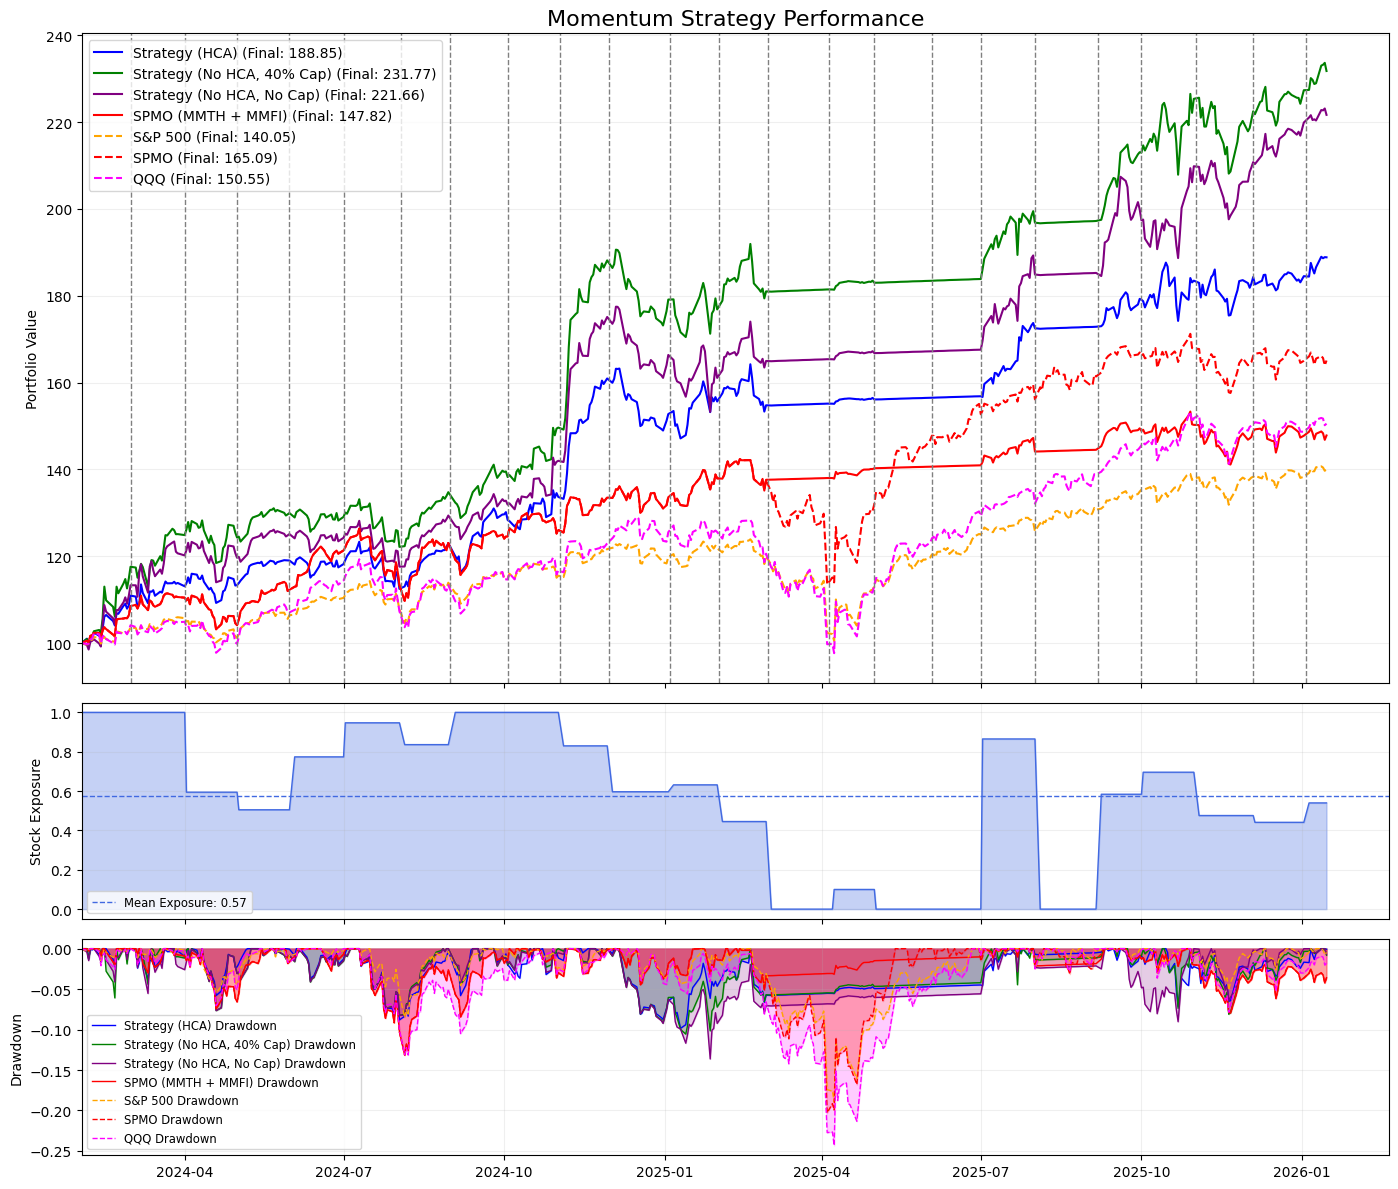

--- Performance Comparison ---
                              CAGR Sharpe Sortino Calmar Annualized Vol   Max DD
Strategy (HCA)              38.50%   2.07    2.67   3.91         17.13%   -9.85%
Strategy (No HCA, 40% Cap)  53.82%   2.45    3.14   5.10         20.77%  -10.56%
Strategy (No HCA, No Cap)   50.34%   2.25    2.79   3.69         21.03%  -13.63%
SPMO (MMTH + MMFI)          22.17%   1.26    1.71   1.68         15.18%  -13.16%
S&P 500                     18.83%   0.99    1.47   1.00         16.01%  -18.90%
SPMO                        29.28%   1.27    1.79   1.44         20.75%  -20.28%
QQQ                         23.32%   0.95    1.43   0.96         21.42%  -24.32%


In [8]:
# --- Configuration & Initialization ---
# Set the base value to 100 for percentage tracking
current_capital_hca = 100.0
current_capital_nohca_cap40 = 100.0
current_capital_nohca_nocap = 100.0
current_capital_spmo = 100.0
transaction_fee_rate = 0.001 # 0.1% per trade

# Risk-free rate assumptions
annual_rf_rate = 0.03 # Assuming 3% annual return on cash
daily_rf_return = (1 + annual_rf_rate) ** (1/252) # Convert annual to daily multiplier

# Exposure levels
prev_exposure = 0.0
mmfi_exposure = 0.1
buy_tqqq = False

# --- EWMA Volatility Targeting ---
nohca_cap40_rets_history = pd.Series(dtype=float)
target_vol = 0.20 # Target annualized volatility of 20%
LAMBDA = 0.94

# Initialize equity and exposure curves
equity_curve_hca = []
equity_curve_nohca_cap40 = []
equity_curve_nohca_nocap = []
equity_curve_spmo = []
equity_dates = []
exposure_curve = [] # Track weighting here

# Retrieve the full trading calendar using the S&P 500 as a reference
sp500_df = get_df("^GSPC", current_date)
spmo_df = get_df("SPMO", current_date)
spmo_df["Daily Return"] = spmo_df["Close"] / spmo_df["Close"].shift(1)
qqq_df = get_df("^IXIC", current_date)
sp500_df["SMA 200"] = SMA(sp500_df, 200)
tqqq_df = get_df("TQQQ", current_date)
tqqq_df["Daily Return"] = tqqq_df["Close"] / tqqq_df["Close"].shift(1)
mmth_df = get_df("MMTH", current_date, method="tradingview")
mmfi_df = get_df("MMFI", current_date, method="tradingview")

# Backtest trading dates
trading_dates = sp500_df.index
backtest_dates = rebalance_dates.copy()
last_trading_date = trading_dates[-1].strftime("%Y-%m-%d")
if backtest_dates[-1] < last_trading_date:
    backtest_dates.append(last_trading_date) # Append the last trading date if not already included

# --- Portfolio Backtest Loop ---
for i in range(len(backtest_dates) - 1):
    rebalance_date = backtest_dates[i]
    next_rebalance_date = backtest_dates[i + 1]
    signal_date = trading_dates[trading_dates <= rebalance_date][-1]
    
    try:
        buy_date = trading_dates[trading_dates > rebalance_date][0]
        valid_sell_dates = trading_dates[trading_dates > next_rebalance_date]
        sell_date = valid_sell_dates[0] if len(valid_sell_dates) > 0 else trading_dates[-1]
    except IndexError:
        print("Reached the end of available trading data.")
        break 

    # Base exposure from MMTH
    current_mmth = mmth_df["Close"].loc[signal_date]
    base_exposure = 0.0 if current_mmth < 50 else 1.0

    # EWMA volatility sizing
    if len(nohca_cap40_rets_history) >= 21:
        ewma_var = nohca_cap40_rets_history.pow(2).ewm(alpha=(1 - LAMBDA), adjust=False).mean().iloc[-1]
        ewma_annual_vol = np.sqrt(ewma_var) * np.sqrt(252) # Estimate annualized volatility
        vol_scale = target_vol / ewma_annual_vol
    else:
        vol_scale = 1.0

    active_exposure = base_exposure * np.clip(vol_scale, 0.0, 1.0)
    active_exposure_spmo = base_exposure

    # Determine the trading period
    period_dates = trading_dates[(trading_dates >= buy_date) & (trading_dates < sell_date)]

    daily_rets_hca = get_period_returns(monthly_portfolios_hca[rebalance_date], period_dates, buy_date, sell_date, sp500_df)
    daily_rets_nohca_cap40 = get_period_returns(monthly_portfolios_nohca_cap40[rebalance_date], period_dates, buy_date, sell_date, sp500_df)
    daily_rets_nohca_nocap = get_period_returns(monthly_portfolios_nohca_nocap[rebalance_date], period_dates, buy_date, sell_date, sp500_df)

    # Update the returns history for EWMA volatility calculation
    period_rets = daily_rets_nohca_cap40.loc[period_dates] - 1.0
    if nohca_cap40_rets_history.empty:
        nohca_cap40_rets_history = period_rets.copy()
    else:
        nohca_cap40_rets_history = pd.concat([nohca_cap40_rets_history, period_rets])

    # --- DAILY EXECUTION LOOP (Handles MMFI Trigger) ---
    # active_exposure = base_exposure
    mmfi_triggered = False
    
    # Apply initial fees
    trade_size = abs(active_exposure - prev_exposure)
    if trade_size > 0:
        fee_factor = 1 - transaction_fee_rate * trade_size
        current_capital_hca *= fee_factor
        current_capital_nohca_cap40 *= fee_factor
        current_capital_nohca_nocap *= fee_factor

    for date in period_dates:
        if buy_tqqq and mmfi_triggered:
            # Calculate today's growth based on the exposure decided YESTERDAY
            growth_hca = growth_nohca_cap40 = growth_nohca_nocap = growth_spmo = (tqqq_df["Daily Return"].loc[date] * active_exposure) + (daily_rf_return * (1 - active_exposure))
        else:
            # Calculate today's growth based on the exposure decided YESTERDAY
            growth_hca = (daily_rets_hca.loc[date] * active_exposure) + (daily_rf_return * (1 - active_exposure))
            growth_nohca_cap40 = (daily_rets_nohca_cap40.loc[date] * active_exposure) + (daily_rf_return * (1 - active_exposure))
            growth_nohca_nocap = (daily_rets_nohca_nocap.loc[date] * active_exposure) + (daily_rf_return * (1 - active_exposure))
            growth_spmo = (spmo_df["Daily Return"].loc[date] * active_exposure_spmo) + (daily_rf_return * (1 - active_exposure_spmo))
 
        # Update capital and equity curves
        current_capital_hca *= growth_hca
        current_capital_nohca_cap40 *= growth_nohca_cap40
        current_capital_nohca_nocap *= growth_nohca_nocap
        current_capital_spmo *= growth_spmo
        equity_curve_hca.append(current_capital_hca)
        equity_curve_nohca_cap40.append(current_capital_nohca_cap40)
        equity_curve_nohca_nocap.append(current_capital_nohca_nocap)
        equity_curve_spmo.append(current_capital_spmo)
        equity_dates.append(date)
        exposure_curve.append(active_exposure) # Record current weight

        # Check for MMFI trigger TODAY to affect TOMORROW'S open
        current_mmfi = mmfi_df["Close"].loc[date]
        
        if not mmfi_triggered and current_mmfi < 10:
            mmfi_triggered = True # Override the logic for the rest of this rebalance period

            # Fee for changing exposure
            trade_size = abs(active_exposure - mmfi_exposure)
            trade_size_spmo = abs(active_exposure_spmo - mmfi_exposure)
            if trade_size > 0:
                fee_factor = (1 - transaction_fee_rate * trade_size)
                current_capital_hca *= fee_factor
                current_capital_nohca_cap40 *= fee_factor
                current_capital_nohca_nocap *= fee_factor
            if trade_size_spmo > 0:
                fee_factor = (1 - transaction_fee_rate * trade_size_spmo)
                current_capital_spmo *= fee_factor

            # This active_exposure will be used starting the NEXT date in the loop
            active_exposure = mmfi_exposure
            active_exposure_spmo = mmfi_exposure
    
    # Update previous exposure for next rebalance
    prev_exposure = active_exposure

# --- Benchmark Processing ---
# Create the portfolio series
strategy_series_hca = pd.Series(equity_curve_hca, index=equity_dates, name="Strategy (HCA)")
strategy_series_nohca_cap40 = pd.Series(equity_curve_nohca_cap40, index=equity_dates, name="Strategy (No HCA, 40% Cap)")
strategy_series_nohca_nocap = pd.Series(equity_curve_nohca_nocap, index=equity_dates, name="Strategy (No HCA, No Cap)")
strategy_series_spmo = pd.Series(equity_curve_spmo, index=equity_dates, name="SPMO (MMTH + MMFI)")

# Normalize strategy to 100 at the start so it aligns with the benchmark
strategy_series_hca = (strategy_series_hca / strategy_series_hca.iloc[0]) * 100
strategy_series_nohca_cap40 = (strategy_series_nohca_cap40 / strategy_series_nohca_cap40.iloc[0]) * 100
strategy_series_nohca_nocap = (strategy_series_nohca_nocap / strategy_series_nohca_nocap.iloc[0]) * 100
strategy_series_spmo = (strategy_series_spmo / strategy_series_spmo.iloc[0]) * 100

# Create the exposure series
exposure_series = pd.Series(exposure_curve, index=equity_dates)

# Align S&P 500: Filter for the same dates and normalize to 100 at the start
sp500_series = sp500_df.loc[strategy_series_hca.index, "Close"]
sp500_series = (sp500_series / sp500_series.iloc[0]) * 100
sp500_series.name = "SP500"
spmo_series = spmo_df.loc[strategy_series_hca.index, "Close"]
spmo_series = (spmo_series / spmo_series.iloc[0]) * 100
spmo_series.name = "SPMO"
qqq_series = qqq_df.loc[strategy_series_hca.index, "Close"]
qqq_series = (qqq_series / qqq_series.iloc[0]) * 100
qqq_series.name = "QQQ"

# Calculate drawdowns
def get_drawdown(series):
    rolling_max = series.cummax()
    return (series - rolling_max) / rolling_max

strat_dd_hca = get_drawdown(strategy_series_hca)
strat_dd_nohca_cap40 = get_drawdown(strategy_series_nohca_cap40)
strat_dd_nohca_nocap = get_drawdown(strategy_series_nohca_nocap)
strat_dd_spmo = get_drawdown(strategy_series_spmo)
sp500_dd = get_drawdown(sp500_series)
spmo_dd = get_drawdown(spmo_series)
qqq_dd = get_drawdown(qqq_series)

# --- Performance Metrics Engine ---
def calculate_metrics(series, annual_rf_rate=0.03):
    # Calculate daily returns for volatility and risk-adjusted ratios
    returns = series.pct_change().dropna()
    
    # Annualized Return (CAGR)
    total_return = (series.iloc[-1] / series.iloc[0]) - 1
    years = (series.index[-1] - series.index[0]).days / 365.25
    cagr = (1 + total_return) ** (1 / years) - 1
    
    # Annualized Volatility
    vol = returns.std() * np.sqrt(252)
    
    # Sharpe Ratio
    sharpe = (cagr - annual_rf_rate) / vol

    # Sortino Ratio (downside deviation only)
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(252)
    sortino = (returns.mean() * 252) / downside_vol
    
    # Maximum Drawdown
    rolling_max = series.cummax()
    drawdowns = (series - rolling_max) / rolling_max
    max_dd = drawdowns.min()
    
    # Calmar Ratio
    calmar = cagr / abs(max_dd)
    
    return {
        "CAGR": f"{cagr:.2%}",
        "Sharpe": f"{sharpe:.2f}",
        "Sortino": f"{sortino:.2f}",
        "Calmar": f"{calmar:.2f}",
        "Annualized Vol": f"{vol:.2%}",
        "Max DD": f"{max_dd:.2%}"
    }

# Calculate metrics for both
strat_metrics_hca = calculate_metrics(strategy_series_hca)
strat_metrics_nohca_cap40 = calculate_metrics(strategy_series_nohca_cap40)
strat_metrics_nohca_nocap = calculate_metrics(strategy_series_nohca_nocap)
strat_metrics_spmo = calculate_metrics(strategy_series_spmo)
sp500_metrics = calculate_metrics(sp500_series)
spmo_metrics = calculate_metrics(spmo_series)
qqq_metrics = calculate_metrics(qqq_series)

# --- Visualization & Comparison ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1]})

# Equity curve
ax1.plot(strategy_series_hca, label=f"Strategy (HCA) (Final: {strategy_series_hca.iloc[-1]:.2f})", color="blue", lw=1.5)
ax1.plot(strategy_series_nohca_cap40, label=f"Strategy (No HCA, 40% Cap) (Final: {strategy_series_nohca_cap40.iloc[-1]:.2f})", color="green", lw=1.5)
ax1.plot(strategy_series_nohca_nocap, label=f"Strategy (No HCA, No Cap) (Final: {strategy_series_nohca_nocap.iloc[-1]:.2f})", color="purple", lw=1.5)
ax1.plot(strategy_series_spmo, label=f"SPMO (MMTH + MMFI) (Final: {strategy_series_spmo.iloc[-1]:.2f})", color="red", lw=1.5)
ax1.plot(sp500_series, label=f"S&P 500 (Final: {sp500_series.iloc[-1]:.2f})", color="orange", lw=1.5, ls="--")
ax1.plot(spmo_series, label=f"SPMO (Final: {spmo_series.iloc[-1]:.2f})", color="red", lw=1.5, ls="--")
ax1.plot(qqq_series, label=f"QQQ (Final: {qqq_series.iloc[-1]:.2f})", color="magenta", lw=1.5, ls="--")
ax1.set_title("Momentum Strategy Performance", fontsize=16)
ax1.set_ylabel("Portfolio Value")
ax1.legend(loc="upper left")
ax1.grid(axis="y", alpha=0.2)
ax1.set_xlim(left=strategy_series_hca.index[0])

# Stock exposure
mean_exposure = exposure_series.mean()
ax2.axhline(y=mean_exposure, color="royalblue", lw=1, ls="--", label=f"Mean Exposure: {mean_exposure:.2f}")
ax2.fill_between(exposure_series.index, exposure_series, color="royalblue", alpha=0.3)
ax2.plot(exposure_series, color="royalblue", lw=1)
ax2.set_ylabel("Stock Exposure")
ax2.legend(loc="lower left", fontsize="small")
ax2.grid(True, alpha=0.2)

# Drawdown
ax3.plot(strat_dd_hca, color="blue", lw=1, label="Strategy (HCA) Drawdown")
ax3.fill_between(strat_dd_hca.index, strat_dd_hca, 0, color="royalblue", alpha=0.2)
ax3.plot(strat_dd_nohca_cap40, color="green", lw=1, label="Strategy (No HCA, 40% Cap) Drawdown")
ax3.fill_between(strat_dd_nohca_cap40.index, strat_dd_nohca_cap40, 0, color="green", alpha=0.2)
ax3.plot(strat_dd_nohca_nocap, color="purple", lw=1, label="Strategy (No HCA, No Cap) Drawdown")
ax3.fill_between(strat_dd_nohca_nocap.index, strat_dd_nohca_nocap, 0, color="purple", alpha=0.2)
ax3.plot(strat_dd_spmo, color="red", lw=1, label="SPMO (MMTH + MMFI) Drawdown")
ax3.fill_between(strat_dd_spmo.index, strat_dd_spmo, 0, color="red", alpha=0.2)
ax3.plot(sp500_dd, color="orange", lw=1, ls="--", label="S&P 500 Drawdown")
ax3.fill_between(sp500_dd.index, sp500_dd, 0, color="orange", alpha=0.2)
ax3.plot(spmo_dd, color="red", lw=1, ls="--", label="SPMO Drawdown")
ax3.fill_between(spmo_dd.index, spmo_dd, 0, color="red", alpha=0.2)
ax3.plot(qqq_dd, color="magenta", lw=1, ls="--", label="QQQ Drawdown")
ax3.fill_between(qqq_dd.index, qqq_dd, 0, color="magenta", alpha=0.2)
ax3.set_ylabel("Drawdown")
ax3.legend(loc="lower left", fontsize="small")
ax3.grid(True, alpha=0.2)

# Add grey vertical lines for rebalance dates
for idx, date in enumerate(pd.to_datetime(backtest_dates)):
    if strategy_series_hca.index.min() <= date <= strategy_series_hca.index.max():
        ax1.axvline(x=date, color="grey", linestyle="--", linewidth=1, label="Rebalance" if idx == 0 else None)
plt.savefig("Result/Figure/momentum_strategy_performance.png", dpi=300)
plt.tight_layout()
plt.show()

# -- Display Comparison Table ---
metrics_df = pd.DataFrame([strat_metrics_hca, strat_metrics_nohca_cap40, strat_metrics_nohca_nocap, strat_metrics_spmo, sp500_metrics, spmo_metrics, qqq_metrics], 
                          index=["Strategy (HCA)", "Strategy (No HCA, 40% Cap)", "Strategy (No HCA, No Cap)", "SPMO (MMTH + MMFI)", "S&P 500", "SPMO", "QQQ"])
print("--- Performance Comparison ---")
print(metrics_df.to_string())

In [14]:
# --- Calculate Number of Shares to Buy in FUTU ---
total_capital = 548900
stock_weight = 0.3
stock_exposure = exposure_series.iloc[-1]

stock_capital = total_capital * stock_weight * stock_exposure

for _, row in current_portfolio_df.iterrows():
    stock = row["Stock"]
    weight = row["Weight (%)"]
    df = get_df(stock, current_date)
    recent_close = df["Close"].iloc[-1]
    num_shares = stock_capital * weight / 100 / 7.8 / recent_close
    print(f"Stock: {stock}, Weight: {weight:.2f}%, Recent Close: {recent_close:.2f}, Shares to Buy: {np.round(num_shares)}")

Stock: SAN, Weight: 16.91%, Recent Close: 12.23, Shares to Buy: 158.0
Stock: SBSW, Weight: 14.35%, Recent Close: 16.77, Shares to Buy: 98.0
Stock: PUK, Weight: 23.09%, Recent Close: 32.08, Shares to Buy: 82.0
Stock: B, Weight: 19.34%, Recent Close: 48.73, Shares to Buy: 45.0
Stock: MT, Weight: 26.30%, Recent Close: 48.73, Shares to Buy: 62.0


In [10]:
# Read and process the Fama-French 5 Factors data
ff5_data = pd.read_csv("Program/F-F_Research_Data_5_Factors_2x3_daily.csv", skiprows=3, index_col=0)
ff5_data = ff5_data.drop(ff5_data.index[-1])

# Convert index to datetime for time series analysis
ff5_data.index = pd.to_datetime(ff5_data.index, format="%Y%m%d")

# Read and process the momentum factor data
ffwml_data = pd.read_csv("Program/F-F_Momentum_Factor_daily.csv", skiprows=13, index_col=0)
ffwml_data = ffwml_data.drop(ffwml_data.index[-1])

# Convert index to datetime for time series analysis
ffwml_data.index = pd.to_datetime(ffwml_data.index, format="%Y%m%d")

# Rename the column from Mom to WML
ffwml_data = ffwml_data.rename(columns={"Mom": "WML"})

In [11]:
def ff6_decompose(df, ff5_data, ffwml_data):
    """
    Decomposes the stock factor into Fama-French 5 factors and WML with optimized performance.

    Parameters:
    df (DataFrame): DataFrame containing stock prices with "Close" column.
    ff5_data (DataFrame): Fama-French 5 factors data.
    ffwml_data (DataFrame): Momentum factor data.
    
    Returns:
    dict: Dictionary containing regression results and additional metrics.
    """
    
    # Calculate daily returns for stock
    stock_returns = df["Close"].pct_change().dropna() * 100
    
    # Get date range
    start_date, end_date = stock_returns.index[0], stock_returns.index[-1]

    # Filter factor data using boolean indexing
    date_mask_ff5 = (ff5_data.index >= start_date) & (ff5_data.index <= end_date)
    date_mask_wml = (ffwml_data.index >= start_date) & (ffwml_data.index <= end_date)
    
    ff5_stock = ff5_data.loc[date_mask_ff5]
    ffwml_stock = ffwml_data.loc[date_mask_wml]
    
    # Combine factors
    factors_stock = ff5_stock[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].join(
        ffwml_stock["WML"], how="inner"
    )

    # Align data using intersection
    common_dates = stock_returns.index.intersection(factors_stock.index)
    stock_aligned = stock_returns.loc[common_dates]
    factors_aligned = factors_stock.loc[common_dates]
    rf_aligned = ff5_stock.loc[common_dates, "RF"]
    
    # Calculate excess returns
    stock_excess = stock_aligned - rf_aligned

    # Remove NaN values
    combined_data = pd.concat([factors_aligned, stock_excess], axis=1)
    clean_data = combined_data.dropna()
    
    X_clean = clean_data.iloc[:, :-1]  # All factors
    y_clean = clean_data.iloc[:, -1]   # Excess returns
    
    # Fit regression model
    model = LinearRegression()
    model.fit(X_clean, y_clean)
    
    # Extract results
    alpha = model.intercept_
    betas = model.coef_
    r_squared = model.score(X_clean, y_clean)

    # Calculate factor contributions
    contributions = pd.DataFrame(
        X_clean.values * betas, 
        index=X_clean.index,
        columns=X_clean.columns
    )
    contributions["Alpha"] = alpha

    # Print results
    print(f"Alpha (intercept): {alpha:.4f}%")
    print(f"R-squared: {r_squared:.4f}")
    print("\nFactor Betas:")

    factor_names = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "WML"]
    for name, beta in zip(factor_names, betas):
        print(f"{name:6s}: {beta:8.4f}")
    
    print(f"\nPeriod: {common_dates[0].strftime('%Y-%m-%d')} to {common_dates[-1].strftime('%Y-%m-%d')}")
    print(f"Number of observations: {len(X_clean)}")
    
    # Return results dictionary
    return {
        "alpha": alpha,
        "betas": betas,
        "r_squared": r_squared,
        "contributions": contributions,
        "n_observations": len(X_clean),
        "period": (common_dates[0], common_dates[-1])
    }

In [12]:
# Add back "Close" column to strategy series for decomposition
strategy_series_hca_df = strategy_series_hca.to_frame(name="Close")
strategy_series_nohca_cap40_df = strategy_series_nohca_cap40.to_frame(name="Close")
strategy_series_nohca_nocap_df = strategy_series_nohca_nocap.to_frame(name="Close")

In [13]:
# Perform Fama-French 6-factor decomposition
ff6_result = ff6_decompose(strategy_series_nohca_cap40_df, ff5_data, ffwml_data)

Alpha (intercept): 0.1189%
R-squared: 0.3259

Factor Betas:
Mkt-RF:   0.3355
SMB   :   0.2270
HML   :  -0.1820
RMW   :  -0.1259
CMA   :  -0.1031
WML   :   0.5637

Period: 2024-02-05 to 2025-11-28
Number of observations: 457
